# Tutorial 11 — Federated Learning and Federated Foundation Models

### Learning Across Power Systems Without Centralizing Their Data

> **Optional / Advanced.** Tutorials 01–10 are the onboarding course and stand
> on their own. This one is for readers who have finished them and want the
> research frontier.

---

## 1. Why federated learning?

Four Distribution System Operators. Each holds something a learning system
would want:

```text
DSO A   feeder topology, line and transformer parameters
DSO B   smart-meter measurements, load profiles
DSO C   PV and EV charging, heat-pump consumption
DSO D   SCADA and voltage measurements, outage and congestion logs
```

Individually, none of them has enough *diversity* to learn a broadly
transferable model — a single operator sees one climate, one settlement
pattern, one regulatory regime. Together they might.

The scientifically convenient architecture is to pool everything:

```text
DSO A ─┐
DSO B ─┼──> Central Database ──> Foundation Model
DSO C ─┤
DSO D ─┘
```

It is frequently not available. Privacy law, commercial confidentiality,
critical-infrastructure rules, contracts, governance and data sovereignty all
bear on whether a feeder model may leave the operator that owns it, and the
answer is often no regardless of how useful pooling would be.

Federated learning is a different architecture for the same goal:

```text
            Global Model
                 │
         ┌───────┼───────┐
         ↓       ↓       ↓
       DSO A   DSO B   DSO C
         │       │       │
      local    local    local
       data     data     data
         │       │       │
         └── updates ────┘
                 │
            Aggregation
                 │
            Global Model
```

### One qualification, before anything else

> **Federated learning is not a synonym for privacy.**

Raw training samples stay with their operator. **Model updates do not.** A
parameter vector is a function of the data that produced it, and §12 shows
how much can be read back out of one. Every claim in this notebook is phrased
to keep that distinction visible, and the wording is deliberate throughout:

| Say | Not |
|---|---|
| raw training samples remain at the client | "no data leaves the client" |
| this bounds one client's influence | "this is differentially private" |
| the server sees only the sum, *if* a protocol enforces it | "secure aggregation is implemented" |

## 2. Learning objectives

By the end of this notebook you can:

- distinguish centralized, distributed and federated learning, and cross-device
  from cross-silo;
- derive and implement Federated Averaging, including why it weights by
  dataset size;
- explain local epochs versus communication rounds, and measure the trade-off;
- recognise statistical heterogeneity, name its four kinds, and measure client
  drift;
- explain what FedProx and SCAFFOLD each try to fix;
- use Flower, after having built the loop by hand;
- explain why data locality is not a privacy guarantee, and what secure
  aggregation and differential privacy each add;
- state a threat model before evaluating any of it;
- run federated self-supervised pretraining and test the representation on an
  operator that never participated;
- compute the communication cost of federating a foundation model, and explain
  why that arithmetic forces parameter-efficient methods;
- federate LoRA adapters over a frozen backbone;
- reason about personalization, fairness across participants, and what should
  be shared at all.

In [1]:
from __future__ import annotations

import copy
import time
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn

from ai_power_course.config import fast_mode, scaled, set_seed
from ai_power_course.federated import (
    ClientData,
    build_dso_clients,
    clip_update,
    communication_table,
    count_parameters,
    describe_clients,
    evaluate,
    federated_average,
    gaussian_noise,
    local_train,
    parameter_delta,
    run_federation,
    standardise_clients,
    state_dict_bytes,
    trainable_state_dict,
)
from ai_power_course.plotting import COLORS, use_course_style

use_course_style()
set_seed()
print(f"reduced (fast) configuration: {fast_mode()}")

# Classroom mode keeps this notebook on a laptop CPU. Extended mode changes
# only SCALE -- more operating points, more rounds -- never a formulation.
N_SAMPLES = scaled(full=160, fast=60)
N_ROUNDS = scaled(full=12, fast=5)

reduced (fast) configuration: False


## 3. Centralized versus federated learning

Three architectures, and the distinction between the last two is the one most
often blurred.

| | Where the data lives | Who optimises | What moves on the wire |
|---|---|---|---|
| **Centralized** | one database | one process | raw data, once |
| **Distributed** | one logical dataset, sharded for speed | many workers, one owner | gradients, every step |
| **Federated** | many owners, never merged | many owners | model updates, every round |

Distributed training shards data *you already own* to go faster. Federated
learning coordinates data *you are not allowed to collect*. The algorithms
look similar; the constraint that produces them is completely different, and
so is the failure mode — a distributed shard is IID by construction, a
federated client is not.

### Cross-device versus cross-silo

| Characteristic | Cross-device | Cross-silo |
|---|---|---|
| Typical clients | phones, meters | organizations |
| Number of clients | $10^5$–$10^9$ | 2–100 |
| Availability | unreliable | contractual |
| Data per client | small | large |
| Compute | constrained | server-grade |
| Energy example | smart meters in homes | DSOs, TSOs, utilities |

**The DSO setting is cross-silo**, and almost every intuition from the
smartphone literature needs re-deriving because of it. With four participants
you cannot rely on sampling many clients per round to average away
heterogeneity: each one is a large, persistent, structurally different
fraction of the federation.

## 4. Simulating multiple DSOs

Four operators, built from four **different pandapower networks** with
different demand and DER regimes. This matters more than it looks: randomly
splitting one homogeneous table would produce clients differing only by
sampling noise, and every method below would score identically on it.

| | Network | Regime |
|---|---|---|
| DSO A | `case33bw` | residential radial feeder, high PV penetration |
| DSO B | `case14` | rural, strong and variable wind |
| DSO C | `case30` | urban, heavy demand with EV charging, little local DER |
| DSO D | `case57` | mixed — **held out**, never participates in training |

The learning task is a **state-estimation surrogate**: predict the network's
minimum bus voltage from aggregate quantities an operator reads off SCADA,
without solving a power flow. Every feature is an aggregate, so the same model
applies to networks of different sizes — which is what makes a shared model
possible at all.

In [2]:
start = time.time()
all_clients = standardise_clients(build_dso_clients(n_samples=N_SAMPLES))
participants = [c for c in all_clients if c.name != "DSO_D"]
heldout = next(c for c in all_clients if c.name == "DSO_D")

print(f"sampled {N_SAMPLES} operating points per DSO in {time.time() - start:.1f}s\n")
display(describe_clients(all_clients).round(4))

sampled 160 operating points per DSO in 19.1s



,description,n_train,n_valid,y_mean,y_std
client,,,,,
DSO_A,"case33bw — residential radial feeder, high PV ...",120,40,0.9208,0.0128
DSO_B,"case14 — rural, strong and variable wind gener...",120,40,1.0098,0.0015
DSO_C,"case30 — urban, heavy demand with EV charging,...",120,40,0.9441,0.0101
DSO_D,case57 — mixed load and generation (held out f...,120,40,0.7241,0.0528


Read the `y_mean` and `y_std` columns rather than taking the word
"heterogeneous" on trust.

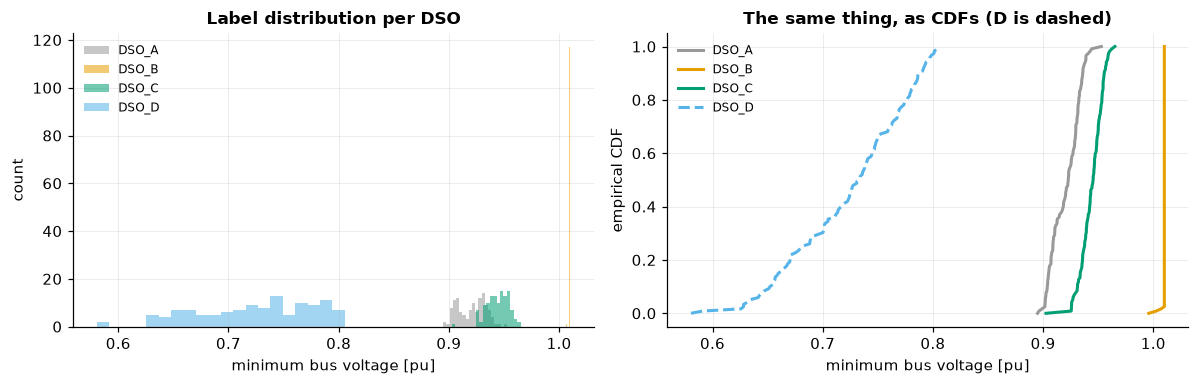

per-DSO mean minimum voltage: {'DSO_A': 0.9208, 'DSO_B': 1.0098, 'DSO_C': 0.9441, 'DSO_D': 0.7241}
spread across operators: 0.2857 pu

This is LABEL DISTRIBUTION SKEW, and it is large. The held-out DSO D is
the most extreme -- a deliberately hard transfer target rather than a
flattering one. Section 21 reports what that costs.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for client in all_clients:
    style = "--" if client.name == "DSO_D" else "-"
    axes[0].hist(
        client.y_train.numpy().ravel(), bins=20, alpha=0.55, label=client.name
    )
    axes[1].plot(
        np.sort(client.y_train.numpy().ravel()),
        np.linspace(0, 1, client.n_train),
        style, lw=2, label=client.name,
    )
axes[0].set_xlabel("minimum bus voltage [pu]")
axes[0].set_ylabel("count")
axes[0].set_title("Label distribution per DSO")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("minimum bus voltage [pu]")
axes[1].set_ylabel("empirical CDF")
axes[1].set_title("The same thing, as CDFs (D is dashed)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

_means = {c.name: float(c.y_train.mean()) for c in all_clients}
_spread = max(_means.values()) - min(_means.values())
print(f"per-DSO mean minimum voltage: "
      f"{ {k: round(v, 4) for k, v in _means.items()} }")
print(f"spread across operators: {_spread:.4f} pu")
print()
print("This is LABEL DISTRIBUTION SKEW, and it is large. The held-out DSO D is")
print("the most extreme -- a deliberately hard transfer target rather than a")
print("flattering one. Section 21 reports what that costs.")

### The four kinds of heterogeneity, in power-system terms

| Kind | In general | Here |
|---|---|---|
| **Quantity skew** | clients hold different amounts | a large urban DSO has more feeders than a rural one |
| **Feature distribution skew** | $P_k(x)$ differs | PV-heavy versus wind-heavy injections |
| **Label distribution skew** | $P_k(y)$ differs | the voltage spread measured above |
| **Concept shift** | $P_k(y \mid x)$ differs | the same injection produces a different voltage on a different topology |

Concept shift is the one that makes grids hard. The first three can be
softened by reweighting; the fourth means the clients do not agree on the
function being learned, because their networks genuinely implement different
functions.

## 5. Local-only models

The first benchmark: each DSO trains alone, on its own data, sharing nothing.

In [4]:
N_FEATURES = all_clients[0].x_train.shape[1]


def make_model() -> nn.Module:
    """The same small MLP everywhere, so every comparison is like-for-like."""
    return nn.Sequential(
        nn.Linear(N_FEATURES, 32), nn.ReLU(), nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1)
    )


LOCAL_EPOCHS = scaled(full=30, fast=12)

local_only: dict[str, float] = {}
for client in participants:
    set_seed()
    model = make_model()
    local_train(model, client.x_train, client.y_train, epochs=LOCAL_EPOCHS, lr=0.02)
    local_only[client.name] = evaluate(model, client.x_valid, client.y_valid)

print("Local-only validation MAE [pu], each DSO on its own data:")
for name, mae in local_only.items():
    print(f"  {name}   {mae:.5f}")
print(f"\nmean {np.mean(list(local_only.values())):.5f}   "
      f"worst {max(local_only.values()):.5f}")

Local-only validation MAE [pu], each DSO on its own data:
  DSO_A   0.03555
  DSO_B   0.03183
  DSO_C   0.04224

mean 0.03654   worst 0.04224


## 6. Centralized benchmark

Now the architecture that is often unavailable: pool the three participants'
data and train one model on the union.

**This is a reference point, not an upper bound.** Federated and centralized
optimization have different dynamics, and there are documented cases where
federation wins — regularisation from averaging, or a client whose data would
be swamped in a pool. Treating centralized as a ceiling is a common and
unearned assumption, so this notebook measures rather than assumes it.

In [5]:
set_seed()
pooled_x = torch.cat([c.x_train for c in participants])
pooled_y = torch.cat([c.y_train for c in participants])
central_model = make_model()
local_train(central_model, pooled_x, pooled_y, epochs=LOCAL_EPOCHS, lr=0.02)

centralized = {
    c.name: evaluate(central_model, c.x_valid, c.y_valid) for c in participants
}
print(f"pooled training set: {len(pooled_x)} samples from "
      f"{len(participants)} operators\n")
print("Centralized validation MAE [pu]:")
for name, mae in centralized.items():
    print(f"  {name}   {mae:.5f}")
print(f"\nmean {np.mean(list(centralized.values())):.5f}   "
      f"worst {max(centralized.values()):.5f}")

pooled training set: 360 samples from 3 operators

Centralized validation MAE [pu]:
  DSO_A   0.03422
  DSO_B   0.05728
  DSO_C   0.02908

mean 0.04019   worst 0.05728


## 7. FedAvg from scratch

Before any framework. One communication round is:

1. the server holds global parameters $w_t$;
2. every client copies them;
3. every client optimises locally on its own data;
4. every client returns $w_{t+1}^{(k)}$;
5. the server aggregates;
6. repeat.

The aggregation is a weighted mean, with client $k$ holding $n_k$ samples:

$$w_{t+1} = \sum_{k=1}^{K} \frac{n_k}{\sum_j n_j}\, w_{t+1}^{(k)}$$

The weighting is not a detail. With one full-batch gradient step per client it
makes the federated update *identical* to one large-batch step over the union
of the data — which is the precise sense in which FedAvg approximates
centralized training, and it breaks as soon as clients take more than one
step. That breakage is §9.

In [6]:
# The whole aggregation, written out.
def federated_average_by_hand(client_states, client_sizes):
    total = sum(client_sizes)
    out = {}
    for key in client_states[0]:
        out[key] = sum(
            state[key] * (size / total)
            for state, size in zip(client_states, client_sizes, strict=True)
        )
    return out


_a = {"w": torch.tensor([1.0, 2.0]), "b": torch.tensor([0.0])}
_b = {"w": torch.tensor([3.0, 4.0]), "b": torch.tensor([2.0])}
_by_hand = federated_average_by_hand([_a, _b], [1, 3])
_library = federated_average([_a, _b], [1, 3])

print("Two clients, sizes 1 and 3, so weights 0.25 and 0.75.")
print(f"  by hand : w = {_by_hand['w'].tolist()}, b = {_by_hand['b'].tolist()}")
print(f"  library : w = {_library['w'].tolist()}, b = {_library['b'].tolist()}")
print("  hand-checked expectation: w = [2.5, 3.5], b = [1.5]")
assert torch.allclose(_by_hand["w"], _library["w"])
assert torch.allclose(_library["w"], torch.tensor([2.5, 3.5]))
print("\nEqual weights would have given [2.0, 3.0] -- which is the answer to a")
print("different question, one where every client counts the same regardless of")
print("how much data stands behind its update.")

Two clients, sizes 1 and 3, so weights 0.25 and 0.75.
  by hand : w = [2.5, 3.5], b = [1.5]
  library : w = [2.5, 3.5], b = [1.5]
  hand-checked expectation: w = [2.5, 3.5], b = [1.5]

Equal weights would have given [2.0, 3.0] -- which is the answer to a
different question, one where every client counts the same regardless of
how much data stands behind its update.


### The loop

`run_federation` is this, with bookkeeping. Nothing in it is hidden:

In [7]:
print(
    """
for round in range(n_rounds):
    client_states = []
    for client in clients:
        model = copy_of(global_model)          # 2. broadcast
        local_train(model, client.data)        # 3. local optimisation
        client_states.append(model.state)      # 4. return update
    global_state = federated_average(          # 5. aggregate
        client_states, [c.n_train for c in clients]
    )
    evaluate(global_state)                     # 6. and repeat
""".strip()
)

for round in range(n_rounds):
    client_states = []
    for client in clients:
        model = copy_of(global_model)          # 2. broadcast
        local_train(model, client.data)        # 3. local optimisation
        client_states.append(model.state)      # 4. return update
    global_state = federated_average(          # 5. aggregate
        client_states, [c.n_train for c in clients]
    )
    evaluate(global_state)                     # 6. and repeat


In [8]:
# 20 local epochs, not 3. Section 9 measures the convergence behaviour that
# justifies this: at 3 local epochs FedAvg has simply not converged after
# N_ROUNDS rounds, and comparing an unconverged federation against fully
# trained local and centralized models would say nothing except that it was
# stopped early. The compute budget is reported below so the comparison stays
# readable rather than merely favourable.
FEDAVG_LOCAL_EPOCHS = 20

set_seed()
fedavg_model, fedavg_history = run_federation(
    make_model, participants, n_rounds=N_ROUNDS,
    local_epochs=FEDAVG_LOCAL_EPOCHS, lr=0.02, seed=0,
)

fedavg = fedavg_history.per_client_mae[-1]
print(f"FedAvg after {N_ROUNDS} rounds x {FEDAVG_LOCAL_EPOCHS} local epochs, "
      f"validation MAE [pu]:")
for name in local_only:
    print(f"  {name}   {fedavg[name]:.5f}")
print(f"\nmean {np.mean([fedavg[n] for n in local_only]):.5f}   "
      f"worst {max(fedavg[n] for n in local_only):.5f}")

FedAvg after 12 rounds x 20 local epochs, validation MAE [pu]:
  DSO_A   0.02948
  DSO_B   0.06363
  DSO_C   0.03096

mean 0.04136   worst 0.06363


### The three benchmarks together

The architectural comparison first — this part is true by construction and
does not depend on any measurement:

| Approach | Raw samples leave the DSO? | Shared model? | Personalization? |
|---|---|---|---|
| Local only | No | No | Yes, entirely |
| Centralized | **Yes** | Yes | No |
| FedAvg | No | Yes | No |
| Personalized FL | No | Partly | Yes |

Now the numbers, which do.

In [9]:
comparison = pd.DataFrame(
    {
        "local only": local_only,
        "centralized": centralized,
        "FedAvg": {n: fedavg[n] for n in local_only},
    }
)
comparison.loc["mean"] = comparison.mean()
comparison.loc["worst client"] = comparison.iloc[:-1].max()
display(comparison.round(5))

_batches = int(np.ceil(participants[0].n_train / 32))
_budget = {
    "local only": LOCAL_EPOCHS * _batches,
    "centralized": LOCAL_EPOCHS * int(np.ceil(len(pooled_x) / 32)),
    "FedAvg": N_ROUNDS * FEDAVG_LOCAL_EPOCHS * _batches,
}
print("Gradient steps taken, per client where applicable:")
for _name, _steps in _budget.items():
    print(f"  {_name:14s} {_steps:5d}")
print()

_best = comparison.loc["mean"].idxmin()
print(f"Lowest mean validation MAE: {_best}")
print()
print("Note the budgets differ. FedAvg spends the most local computation and")
print("still has to reconcile three divergent updates every round, which is")
print("the cost of the architecture rather than a tuning failure -- section 9")
print("shows the same model converging as the local budget grows.")
print()
print("Read this table as a measurement, not as a result that was aimed for.")
print("If centralized wins, that is the cost of the privacy constraint and it")
print("should be stated as such. If a local model wins for one DSO, that DSO")
print("has enough data for its own problem and the federation is not helping")
print("it -- which section 20 addresses with personalization rather than by")
print("hiding the number in a mean.")

,local only,centralized,FedAvg
DSO_A,0.03555,0.03422,0.02948
DSO_B,0.03183,0.05728,0.06363
DSO_C,0.04224,0.02908,0.03096
mean,0.03654,0.04019,0.04136
worst client,0.04224,0.05728,0.06363


Gradient steps taken, per client where applicable:
  local only       120
  centralized      360
  FedAvg           960

Lowest mean validation MAE: local only

Note the budgets differ. FedAvg spends the most local computation and
still has to reconcile three divergent updates every round, which is
the cost of the architecture rather than a tuning failure -- section 9
shows the same model converging as the local budget grows.

Read this table as a measurement, not as a result that was aimed for.
If centralized wins, that is the cost of the privacy constraint and it
should be stated as such. If a local model wins for one DSO, that DSO
has enough data for its own problem and the federation is not helping
it -- which section 20 addresses with personalization rather than by
hiding the number in a mean.


## 8. IID versus non-IID clients

The experiment above used genuinely different grids. To see what that costs,
compare it against an artificially homogeneous federation: the *same* pooled
data, shuffled and dealt out at random. That is the IID control, and it is the
regime most federated-learning papers implicitly assume.

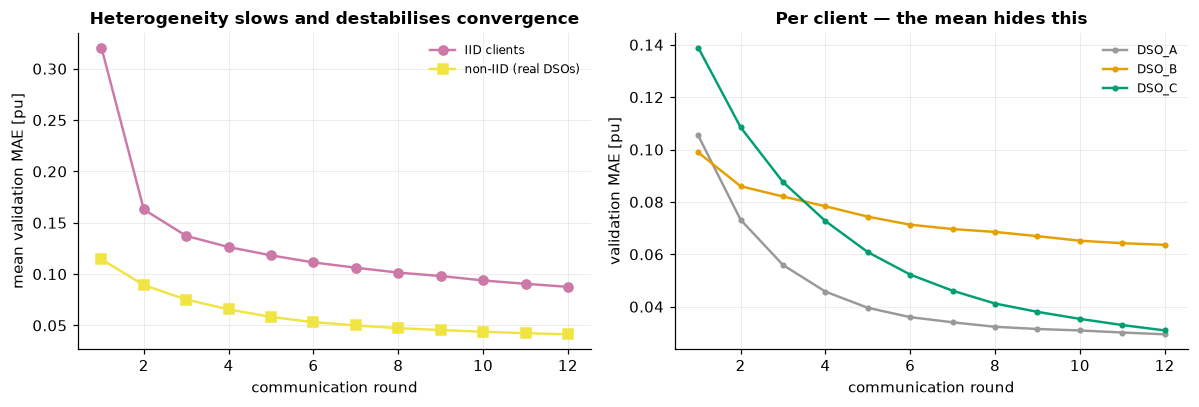

final mean MAE, IID clients     : 0.08757
final mean MAE, real DSOs       : 0.04136
final worst client, real DSOs   : 0.06363
spread across clients           : 0.01576

The right-hand panel is the point. One global number can improve while
an individual operator gets worse, and only the per-client curves show
it. Report both, always.


In [10]:
def make_iid_clients(source: list[ClientData], seed: int = 0) -> list[ClientData]:
    """Pool everything, shuffle, deal back out. Destroys all heterogeneity."""
    x = torch.cat([c.x_train for c in source])
    y = torch.cat([c.y_train for c in source])
    xv = torch.cat([c.x_valid for c in source])
    yv = torch.cat([c.y_valid for c in source])
    g = torch.Generator().manual_seed(seed)
    order = torch.randperm(len(x), generator=g)
    order_v = torch.randperm(len(xv), generator=g)
    chunks = torch.chunk(order, len(source))
    chunks_v = torch.chunk(order_v, len(source))
    return [
        ClientData(
            name=f"IID_{i}",
            x_train=x[c], y_train=y[c],
            x_valid=xv[cv], y_valid=yv[cv],
            description="artificially homogeneous",
        )
        for i, (c, cv) in enumerate(zip(chunks, chunks_v, strict=True))
    ]


iid_clients = make_iid_clients(participants)
set_seed()
_, iid_history = run_federation(
    make_model, iid_clients, n_rounds=N_ROUNDS, local_epochs=3, lr=0.02, seed=0
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(iid_history.rounds, iid_history.global_mae, "o-",
             color=COLORS["foundation"], label="IID clients")
axes[0].plot(fedavg_history.rounds, fedavg_history.global_mae, "s-",
             color=COLORS["accent"], label="non-IID (real DSOs)")
axes[0].set_xlabel("communication round")
axes[0].set_ylabel("mean validation MAE [pu]")
axes[0].set_title("Heterogeneity slows and destabilises convergence")
axes[0].legend(fontsize=8)

for name in local_only:
    axes[1].plot(
        fedavg_history.rounds,
        [r[name] for r in fedavg_history.per_client_mae],
        "o-", ms=3, label=name,
    )
axes[1].set_xlabel("communication round")
axes[1].set_ylabel("validation MAE [pu]")
axes[1].set_title("Per client — the mean hides this")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"final mean MAE, IID clients     : {iid_history.global_mae[-1]:.5f}")
print(f"final mean MAE, real DSOs       : {fedavg_history.global_mae[-1]:.5f}")
print(f"final worst client, real DSOs   : {fedavg_history.worst_client():.5f}")
print(f"spread across clients           : {fedavg_history.client_spread():.5f}")
print()
print("The right-hand panel is the point. One global number can improve while")
print("an individual operator gets worse, and only the per-client curves show")
print("it. Report both, always.")

## 9. Client drift

FedAvg's approximation to centralized training holds for *one* local step.
Take many, and each client walks toward its own local optimum before anyone
averages. The average of four points that each moved somewhere different is
not close to any of them.

The trade-off is real and it cuts both ways: more local epochs means fewer
communication rounds for the same amount of computation, which is exactly what
you want when the network is the bottleneck. It also means more drift.

Measure it. `drift` below is the mean L2 distance from each client's
post-training parameters to the global parameters the round started from.

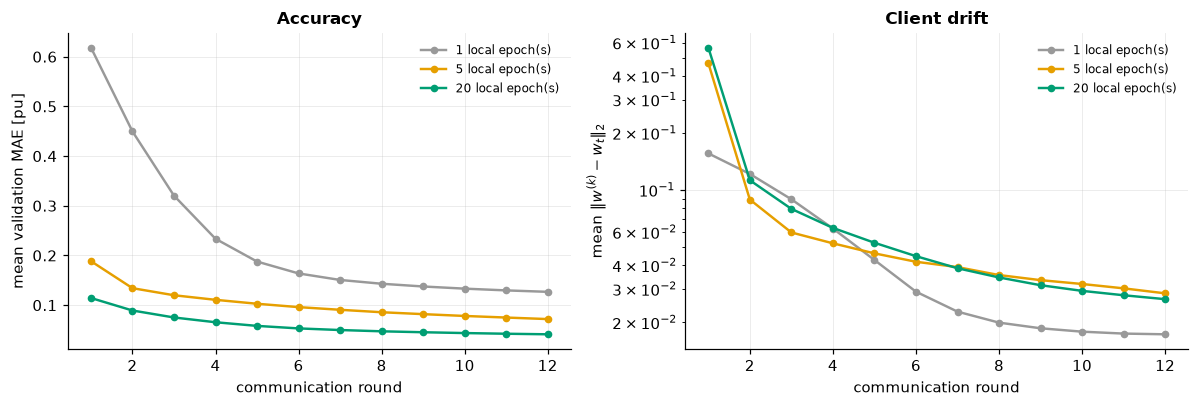

,final mean MAE,final worst client,final drift,local gradient steps
local epochs,,,,
1,0.12681,0.15070,0.01727,48
5,0.07198,0.08267,0.02843,240
20,0.04136,0.06363,0.02648,960


final drift by local epochs (1, 5, 20): [0.01727, 0.02843, 0.02648]
monotonically increasing in local epochs: False
lowest final mean MAE at 20 local epoch(s)

Two things worth reading off this rather than assuming.

Drift grows once clients do real local work, but it is NOT monotonic
here -- it peaks and then falls back, because by 20 epochs each client
has converged to its own optimum and stops moving further. Drift
measures disagreement between clients, not how hard they worked.

Accuracy improves throughout this range, so on this federation more
local computation is the better trade. That is a property of a small,
cheap, well-conditioned problem. Push the local budget far enough, or
make the clients more different, and it reverses -- which is exactly
the regime FedProx in the next section is built for.


In [11]:
DRIFT_EPOCHS = (1, 5, 20)
drift_runs = {}
for epochs in DRIFT_EPOCHS:
    set_seed()
    _, history = run_federation(
        make_model, participants, n_rounds=N_ROUNDS,
        local_epochs=epochs, lr=0.02, seed=0,
    )
    drift_runs[epochs] = history

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for epochs, history in drift_runs.items():
    axes[0].plot(history.rounds, history.global_mae, "o-", ms=4,
                 label=f"{epochs} local epoch(s)")
    axes[1].plot(history.rounds, history.drift, "o-", ms=4,
                 label=f"{epochs} local epoch(s)")
axes[0].set_xlabel("communication round")
axes[0].set_ylabel("mean validation MAE [pu]")
axes[0].set_title("Accuracy")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("communication round")
axes[1].set_ylabel(r"mean $\|w^{(k)} - w_t\|_2$")
axes[1].set_title("Client drift")
axes[1].set_yscale("log")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

drift_table = pd.DataFrame(
    {
        "final mean MAE": {e: h.global_mae[-1] for e, h in drift_runs.items()},
        "final worst client": {e: h.worst_client() for e, h in drift_runs.items()},
        "final drift": {e: h.drift[-1] for e, h in drift_runs.items()},
        "local gradient steps": {
            e: e * N_ROUNDS * int(np.ceil(participants[0].n_train / 32))
            for e in drift_runs
        },
    }
)
drift_table.index.name = "local epochs"
display(drift_table.round(5))

_best_epochs = drift_table["final mean MAE"].idxmin()
_drifts = drift_table["final drift"].tolist()
_monotonic = all(a <= b for a, b in zip(_drifts[:-1], _drifts[1:], strict=True))
print(f"final drift by local epochs {DRIFT_EPOCHS}: "
      f"{[round(d, 5) for d in _drifts]}")
print(f"monotonically increasing in local epochs: {_monotonic}")
print(f"lowest final mean MAE at {_best_epochs} local epoch(s)")
print()
print("Two things worth reading off this rather than assuming.")
print()
print("Drift grows once clients do real local work, but it is NOT monotonic")
print("here -- it peaks and then falls back, because by 20 epochs each client")
print("has converged to its own optimum and stops moving further. Drift")
print("measures disagreement between clients, not how hard they worked.")
print()
print("Accuracy improves throughout this range, so on this federation more")
print("local computation is the better trade. That is a property of a small,")
print("cheap, well-conditioned problem. Push the local budget far enough, or")
print("make the clients more different, and it reverses -- which is exactly")
print("the regime FedProx in the next section is built for.")

## 10. FedProx

FedProx (Li et al., 2020) changes exactly one thing: it adds a proximal term
to the local objective, penalising movement away from the global parameters
the round started from.

$$\min_w \; F_k(w) \;+\; \frac{\mu}{2}\,\lVert w - w^{t} \rVert^2$$

$\mu = 0$ is FedAvg. That is the whole difference, which makes the comparison
unusually clean.

**SCAFFOLD** (Karimireddy et al., 2020) attacks the same problem differently:
instead of penalising drift it *corrects* for it, maintaining control variates
$c$ and $c_k$ that estimate the difference between the global and local update
directions, and steering each local step by $-c_k + c$. It removes drift
rather than discouraging it, at the cost of extra state on every client and
double the communication. It stays conceptual here.

,final mean MAE,final worst client,client spread,final drift
mu (0 = FedAvg),,,,
0.00,0.04136,0.06363,0.01576,0.02648
0.01,0.04146,0.06371,0.01575,0.02644
0.10,0.04240,0.06446,0.01564,0.02624
1.00,0.05363,0.07277,0.01486,0.02568


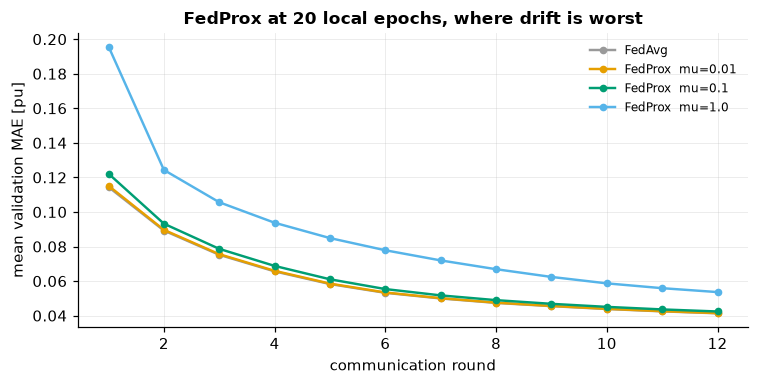

lowest final mean MAE at mu = 0.0
drift falls monotonically as mu grows: True
mu = 1.0 reduces drift by 3.0% and changes mean MAE by +29.7%

The proximal term moves drift in the direction it is designed to, and
by very little -- a few per cent for a hundredfold change in mu. On
this federation FedProx buys nothing, and the honest reading is that
the problem it fixes is not the problem this experiment has: three
clients on a small, well-conditioned regression converge compatibly
enough that there is no drift worth correcting.

That is a useful negative result. FedProx earns its keep on federations
with many more clients, far stronger heterogeneity, and stragglers
doing variable amounts of local work -- none of which a laptop-scale
notebook reproduces. Do not read this table as evidence against the
method; read it as evidence that this benchmark cannot test it.


In [12]:
MU_VALUES = (0.0, 0.01, 0.1, 1.0)
prox_runs = {}
for mu in MU_VALUES:
    set_seed()
    _, history = run_federation(
        make_model, participants, n_rounds=N_ROUNDS,
        local_epochs=20, lr=0.02, mu=mu, seed=0,
    )
    prox_runs[mu] = history

prox_table = pd.DataFrame(
    {
        "final mean MAE": {m: h.global_mae[-1] for m, h in prox_runs.items()},
        "final worst client": {m: h.worst_client() for m, h in prox_runs.items()},
        "client spread": {m: h.client_spread() for m, h in prox_runs.items()},
        "final drift": {m: h.drift[-1] for m, h in prox_runs.items()},
    }
)
prox_table.index.name = "mu (0 = FedAvg)"
display(prox_table.round(5))

fig, ax = plt.subplots(figsize=(7, 3.6))
for mu, history in prox_runs.items():
    label = "FedAvg" if mu == 0 else f"FedProx  mu={mu}"
    ax.plot(history.rounds, history.global_mae, "o-", ms=4, label=label)
ax.set_xlabel("communication round")
ax.set_ylabel("mean validation MAE [pu]")
ax.set_title("FedProx at 20 local epochs, where drift is worst")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

_mu_best = prox_table["final mean MAE"].idxmin()
_prox_drifts = prox_table["final drift"].tolist()
_prox_monotonic = all(
    a >= b for a, b in zip(_prox_drifts[:-1], _prox_drifts[1:], strict=True)
)
_drift_drop = 1 - _prox_drifts[-1] / _prox_drifts[0]
print(f"lowest final mean MAE at mu = {_mu_best}")
print(f"drift falls monotonically as mu grows: {_prox_monotonic}")
print(f"mu = {MU_VALUES[-1]} reduces drift by {_drift_drop:.1%} and changes mean "
      f"MAE by {prox_table['final mean MAE'].iloc[-1] / prox_table['final mean MAE'].iloc[0] - 1:+.1%}")
print()
print("The proximal term moves drift in the direction it is designed to, and")
print("by very little -- a few per cent for a hundredfold change in mu. On")
print("this federation FedProx buys nothing, and the honest reading is that")
print("the problem it fixes is not the problem this experiment has: three")
print("clients on a small, well-conditioned regression converge compatibly")
print("enough that there is no drift worth correcting.")
print()
print("That is a useful negative result. FedProx earns its keep on federations")
print("with many more clients, far stronger heterogeneity, and stragglers")
print("doing variable amounts of local work -- none of which a laptop-scale")
print("notebook reproduces. Do not read this table as evidence against the")
print("method; read it as evidence that this benchmark cannot test it.")

## 11. Flower

The loop above *is* the algorithm. What it is not is an orchestration system:
no message serialisation, no client lifecycle, no failure handling, no way to
run the clients as separate processes or machines.

[Flower](https://flower.ai) supplies that layer. The mapping is one-to-one:

| What we built | Flower |
|---|---|
| a `ClientData` and its loop body | `ClientApp` / `NumPyClient.fit` |
| `copy_of(global_model)` | parameters passed into `fit` |
| returning `model.state_dict()` | the ndarrays returned from `fit` |
| `federated_average(...)` | `strategy=FedAvg(...)` |
| one pass of the `for` loop | one server round |

Same model, same data, same algorithm — different plumbing. Run it and compare
the number against the hand-written loop.

In [13]:
from flwr.client import ClientApp, NumPyClient
from flwr.common import Context, ndarrays_to_parameters
from flwr.server import ServerApp, ServerAppComponents, ServerConfig
from flwr.server.strategy import FedAvg as FlowerFedAvg
from flwr.simulation import run_simulation


def get_ndarrays(model: nn.Module) -> list[np.ndarray]:
    return [v.cpu().numpy() for v in model.state_dict().values()]


def set_ndarrays(model: nn.Module, arrays: list[np.ndarray]) -> None:
    state = model.state_dict()
    for key, value in zip(state.keys(), arrays, strict=True):
        state[key] = torch.tensor(value)
    model.load_state_dict(state, strict=True)


class DSOClient(NumPyClient):
    """One DSO. `fit` is the body of our loop; Flower calls it."""

    def __init__(self, client: ClientData) -> None:
        self.client = client
        self.model = make_model()

    def fit(self, parameters, config):
        set_ndarrays(self.model, parameters)
        local_train(
            self.model, self.client.x_train, self.client.y_train,
            epochs=3, lr=0.02,
        )
        return get_ndarrays(self.model), self.client.n_train, {}

    def evaluate(self, parameters, config):
        set_ndarrays(self.model, parameters)
        mae = evaluate(self.model, self.client.x_valid, self.client.y_valid)
        return float(mae), int(self.client.x_valid.shape[0]), {"mae": float(mae)}


def client_fn(context: Context):
    partition = int(context.node_config["partition-id"])
    return DSOClient(participants[partition]).to_client()


def weighted_mae(metrics):
    total = sum(n for n, _ in metrics)
    return {"mae": sum(n * m["mae"] for n, m in metrics) / total}


def server_fn(context: Context):
    set_seed()
    strategy = FlowerFedAvg(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_available_clients=len(participants),
        initial_parameters=ndarrays_to_parameters(get_ndarrays(make_model())),
        evaluate_metrics_aggregation_fn=weighted_mae,
    )
    return ServerAppComponents(
        strategy=strategy, config=ServerConfig(num_rounds=N_ROUNDS)
    )


set_seed()
_t = time.time()
run_simulation(
    server_app=ServerApp(server_fn=server_fn),
    client_app=ClientApp(client_fn=client_fn),
    num_supernodes=len(participants),
    backend_config={"client_resources": {"num_cpus": 1, "num_gpus": 0.0}},
)
print(f"\nFlower simulation finished in {time.time() - _t:.1f}s")
print(f"hand-written loop, final mean MAE : {fedavg_history.global_mae[-1]:.5f}")
print()
print("Flower reports its own aggregated MAE in the log above. The two are the")
print("same algorithm on the same data; small differences come from batch")
print("ordering and client scheduling, not from a different method.")


            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        


INFO :      Starting Flower ServerApp, config: num_rounds=12, no round_timeout


INFO :      


INFO :      [INIT]


INFO :      Using initial global parameters provided by strategy


...

INFO :      	         (11, 0.049753908067941666),


INFO :      	         (12, 0.04859383155902227)]}


INFO :      


(ClientAppActor pid=1400163) WARNING :   Manually terminating ClientAppActor
(ClientAppActor pid=1400152) WARNING :   Manually terminating ClientAppActor [repeated 19x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)



Flower simulation finished in 21.8s
hand-written loop, final mean MAE : 0.04136

Flower reports its own aggregated MAE in the log above. The two are the
same algorithm on the same data; small differences come from batch
ordering and client scheduling, not from a different method.


### What actually goes over the wire

Federated learning becomes much less mysterious once you look at the payload.

In [14]:
_probe = make_model()
_state = _probe.state_dict()
rows = [
    {"tensor": k, "shape": tuple(v.shape), "values": v.numel(),
     "dtype": str(v.dtype).replace("torch.", ""),
     "bytes": v.numel() * v.element_size()}
    for k, v in _state.items()
]
display(pd.DataFrame(rows).set_index("tensor"))
print(f"one message: {state_dict_bytes(_state):,} bytes "
      f"({state_dict_bytes(_state) / 1024:.1f} KiB)")
print(f"per round, {len(participants)} clients, both directions: "
      f"{2 * len(participants) * state_dict_bytes(_state) / 1024:.1f} KiB")
print()
print("That is the entire content of a communication round: these tensors,")
print("twice per client per round. No feeder models, no measurements -- and")
print("also no guarantee that these numbers reveal nothing about them.")

,shape,values,dtype,bytes
tensor,,,,
0.weight,"(32, 8)",256,float32,1024
0.bias,"(32,)",32,float32,128
2.weight,"(16, 32)",512,float32,2048
2.bias,"(16,)",16,float32,64
4.weight,"(1, 16)",16,float32,64
4.bias,"(1,)",1,float32,4


one message: 3,332 bytes (3.3 KiB)
per round, 3 clients, both directions: 19.5 KiB

That is the entire content of a communication round: these tensors,
twice per client per round. No feeder models, no measurements -- and
also no guarantee that these numbers reveal nothing about them.


## 12. Privacy is not automatic

# Does federated learning guarantee privacy?

**No.**

Raw training samples remain with their operator. That is a real and useful
property, and it is the *only* one the architecture provides by itself.
Information can still flow through:

- **gradients** — the classic result. Zhu et al., *Deep Leakage from
  Gradients* (NeurIPS 2019) reconstruct training samples pixel-for-pixel from
  a shared gradient; Geiping et al. (2020) extended it to realistic batch
  sizes and architectures.
- **parameter updates** — a difference of parameters is an accumulated
  gradient.
- **embeddings and activations**, in split or vertical architectures.
- **repeated observation** — a client seen over many rounds leaks more than
  one seen once.
- **membership inference** — often the realistic worry: not "reconstruct this
  household's profile" but "was this feeder in the training set", which can
  itself be commercially or legally sensitive.

### A safe demonstration

No reconstruction attack here. Instead, the property that makes such attacks
possible in the first place: an update is a *deterministic function of the
data*, so different data produce reliably different updates. Anything with a
reliable signal in it can be inverted given enough effort.

In [15]:
set_seed()
_global = make_model()
_global_state = {k: v.clone() for k, v in _global.state_dict().items()}


def update_from(x, y, epochs=5):
    model = make_model()
    model.load_state_dict(copy.deepcopy(_global_state))
    local_train(model, x, y, epochs=epochs, lr=0.02)
    delta = parameter_delta(model.state_dict(), _global_state)
    return torch.cat([v.flatten() for v in delta.values()])


_a = participants[0]
_u1 = update_from(_a.x_train[:20], _a.y_train[:20])
_u2 = update_from(_a.x_train[:20], _a.y_train[:20])          # same data again
_u3 = update_from(_a.x_train[20:40], _a.y_train[20:40])      # different subset
_u4 = update_from(participants[2].x_train[:20], participants[2].y_train[:20])


def cosine(a, b):
    return float(torch.dot(a, b) / (a.norm() * b.norm()))


print("Cosine similarity between update vectors:")
print(f"  same data, twice                  {cosine(_u1, _u2):+.4f}")
print(f"  different subset, same DSO        {cosine(_u1, _u3):+.4f}")
print(f"  different DSO entirely           {cosine(_u1, _u4):+.4f}")
print()
print("The update is essentially determined by the data that produced it. A")
print("server holding these vectors is not holding noise -- it is holding a")
print("high-dimensional, reproducible function of a private dataset. That is")
print("the opening an inversion attack works through.")
print()
print("Take from this the direction of the claim, not a threat level. It shows")
print("updates CARRY information; it does not measure how much is recoverable,")
print("which depends on the model, the batch size and the attacker.")

Cosine similarity between update vectors:
  same data, twice                  +1.0000
  different subset, same DSO        +0.9894
  different DSO entirely           +0.9852

The update is essentially determined by the data that produced it. A
server holding these vectors is not holding noise -- it is holding a
high-dimensional, reproducible function of a private dataset. That is
the opening an inversion attack works through.

Take from this the direction of the claim, not a threat level. It shows
updates CARRY information; it does not measure how much is recoverable,
which depends on the model, the batch size and the attacker.


### Threat model: who are we protecting against?

None of the mechanisms below can be evaluated without naming an adversary.

| Adversary | Sees | Mitigated mainly by |
|---|---|---|
| Honest-but-curious server | every client update, every round | secure aggregation |
| Malicious server | can also send crafted parameters | secure aggregation + attestation |
| Another participating DSO | the global model each round | differential privacy |
| External attacker | whatever the transport leaks | ordinary transport security |
| Malicious client | the global model; can poison updates | robust aggregation, anomaly detection |

For critical infrastructure the second and last rows deserve more weight than
the literature's usual focus on the first. A competitor DSO inside the
federation and a compromised participant are both realistic, and they are
defended against by different mechanisms.

## 13. Differential privacy

Differential privacy bounds how much any single unit of data can influence an
output. A mechanism $M$ is $(\epsilon, \delta)$-differentially private if for
neighbouring datasets $D, D'$ differing in one unit, and any outcome set $S$:

$$\Pr[M(D) \in S] \;\le\; e^{\epsilon}\,\Pr[M(D') \in S] \;+\; \delta$$

Read it as: the output distribution barely changes when one record is added or
removed, so observing the output tells you little about whether that record
was present.

In federated learning the construction is:

1. **clip** each client update to a fixed norm $C$ — bounds one client's
   influence, which is what makes a noise level meaningful;
2. **add** Gaussian noise calibrated to $C$ and the target $(\epsilon,
   \delta)$;
3. **account** for the budget spent across rounds, since privacy loss
   composes.

### What follows is steps 1 and 2 only

> There is **no accountant here and no epsilon**. The noise is not calibrated
> to a privacy target. This measures the *utility cost* of adding noise, which
> is a real and useful thing to see, and it is **not** a differentially
> private mechanism. Quoting an $\epsilon$ for it would be wrong. For real
> work use Opacus or Flower's DP modifiers, which implement the accountant.

,clip norm,noise std,mean MAE,worst client
setting,,,,
"no clipping, no noise",NaN,0.000,0.08865,0.10715
clip only,1.0,0.000,0.08865,0.10715
clip + low noise,1.0,0.002,0.08810,0.10588
clip + moderate noise,1.0,0.010,0.08531,0.10303
clip + high noise,1.0,0.050,0.12236,0.15743


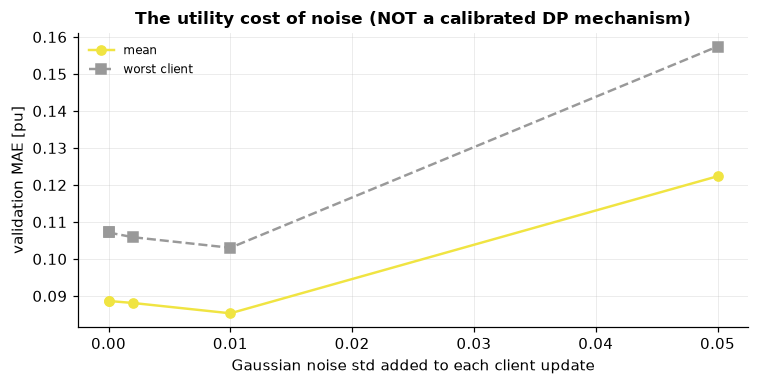

mean MAE, no noise        : 0.08865
mean MAE, highest noise   : 0.12236
relative degradation      : +38.0%

The shape of this curve is the privacy-utility trade-off. More noise
means a weaker link between any one client's data and the published
model, and a worse model. There is no setting that avoids the trade;
there is only a choice about where on it to sit.

One power-system-specific worry, which the curve does not show: the
events worth learning from -- the rare overload, the unusual outage --
are exactly the ones a privacy mechanism is designed to hide, because
they are the most identifying. Whether DP can preserve rare grid events
is an open question, not a solved one.


In [16]:
DP_SETTINGS = [
    ("no clipping, no noise", None, 0.0),
    ("clip only", 1.0, 0.0),
    ("clip + low noise", 1.0, 0.002),
    ("clip + moderate noise", 1.0, 0.01),
    ("clip + high noise", 1.0, 0.05),
]

dp_rows = []
for label, clip, noise in DP_SETTINGS:
    set_seed()
    _, history = run_federation(
        make_model, participants, n_rounds=N_ROUNDS, local_epochs=3, lr=0.02,
        clip_norm=clip, noise_std=noise, seed=0,
    )
    dp_rows.append(
        {
            "setting": label,
            "clip norm": clip if clip is not None else float("nan"),
            "noise std": noise,
            "mean MAE": history.global_mae[-1],
            "worst client": history.worst_client(),
        }
    )

dp_table = pd.DataFrame(dp_rows).set_index("setting")
display(dp_table.round(5))

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(dp_table["noise std"], dp_table["mean MAE"], "o-",
        color=COLORS["accent"], label="mean")
ax.plot(dp_table["noise std"], dp_table["worst client"], "s--",
        color=COLORS["baseline"], label="worst client")
ax.set_xlabel("Gaussian noise std added to each client update")
ax.set_ylabel("validation MAE [pu]")
ax.set_title("The utility cost of noise (NOT a calibrated DP mechanism)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

_clean = dp_table.loc["no clipping, no noise", "mean MAE"]
_noisy = dp_table.loc["clip + high noise", "mean MAE"]
print(f"mean MAE, no noise        : {_clean:.5f}")
print(f"mean MAE, highest noise   : {_noisy:.5f}")
print(f"relative degradation      : {_noisy / _clean - 1:+.1%}")
print()
print("The shape of this curve is the privacy-utility trade-off. More noise")
print("means a weaker link between any one client's data and the published")
print("model, and a worse model. There is no setting that avoids the trade;")
print("there is only a choice about where on it to sit.")
print()
print("One power-system-specific worry, which the curve does not show: the")
print("events worth learning from -- the rare overload, the unusual outage --")
print("are exactly the ones a privacy mechanism is designed to hide, because")
print("they are the most identifying. Whether DP can preserve rare grid events")
print("is an open question, not a solved one.")

## 14. Secure aggregation

Secure aggregation solves a *different* problem from differential privacy, and
conflating the two is the most common error in this area.

```text
Without secure aggregation, the server sees:
    Δw_A ,  Δw_B ,  Δw_C ,  Δw_D

With secure aggregation, the server learns only:
    Δw_A + Δw_B + Δw_C + Δw_D
```

Each client masks its update with pairwise secrets that cancel in the sum
(Bonawitz et al., CCS 2017). The server can decrypt the total and nothing
else.

| Mechanism | What it protects | What it does not |
|---|---|---|
| Federated learning | raw samples stay local | updates still leave |
| Secure aggregation | server cannot inspect an individual update | the *sum* still encodes information |
| Differential privacy | bounds any one unit's influence on the output | costs accuracy; needs an accountant |

They compose: secure aggregation hides individuals from the server, DP bounds
what the aggregate itself reveals. Neither makes a system "secure", and a
federation with four participants has a specific weakness — with $K = 4$, a
server colluding with two participants can isolate a third from the sum.

> `federated_average` in this course computes the sum in plaintext. It
> **simulates** the arithmetic that secure aggregation would protect. Calling
> that "secure aggregation" would be false, so this notebook does not.

## 15. From federated learning to federated foundation models

Everything so far federated a *task-specific* model. Now combine the two
paradigm shifts this course has covered.

```text
                     CENTRALIZED            FEDERATED
                         │                      │
Task-specific            │  a trained model     │  Federated ML
                         │  (Tutorials 01-03)   │  (sections 1-14)
─────────────────────────┼──────────────────────┼──────────────────
                         │                      │
Foundation model         │  Foundation Model    │  FEDERATED
                         │  (Tutorials 08-10)   │  FOUNDATION MODEL
```

The axes are independent: *model generality* and *data decentralization*.

Tutorial 10 pretrained one encoder across five grids held in one place:

```text
Grid A ─┐
Grid B ─┼──> Central pretraining ──> GridFM
Grid C ─┘
```

The federated question is whether that same representation can be learned when
each grid belongs to a different operator who will not hand it over:

```text
DSO A: Grid A ─┐
DSO B: Grid B ─┼──> Federated pretraining ──> FedGridFM
DSO C: Grid C ─┘
```

### Four lifecycle architectures

"Federated foundation model" does not mean one thing. At least four
arrangements exist, and they have different costs:

| | Pretraining | Adaptation | When it fits |
|---|---|---|---|
| **A** | federated, on private data | central | no public corpus exists for the domain |
| **B** | central, on public data | federated on private data | a good general model already exists |
| **C** | central | local adapters, never aggregated | participants want no coupling at all |
| **D** | federated | federated | the strictest setting, and the most expensive |

For grids, **B** is the pragmatic near-term option and **A** is the research
question, because there is no public corpus of feeder models and measurements
to pretrain on centrally. That absence is precisely why federated pretraining
is interesting here rather than merely possible.

## 16. Why full-model federation becomes difficult

Do the arithmetic before reaching for a method. A foundation model with
$10^9$ parameters in float32:

In [17]:
def communication_estimate(n_params, n_clients, n_rounds, bytes_per_param=4):
    per_message = n_params * bytes_per_param
    per_round = per_message * n_clients * 2      # down to clients, back up
    return {
        "parameters": n_params,
        "GB per message": per_message / 1e9,
        "GB per round": per_round / 1e9,
        "TB total": per_round * n_rounds / 1e12,
    }


scales = pd.DataFrame(
    [
        {"model": "our MLP", **communication_estimate(
            sum(p.numel() for p in make_model().parameters()), 4, 100)},
        {"model": "Mini-GridFM (~100k)", **communication_estimate(100_000, 4, 100)},
        {"model": "small LM (125M)", **communication_estimate(125_000_000, 100, 100)},
        {"model": "1B foundation model", **communication_estimate(1_000_000_000, 100, 100)},
    ]
).set_index("model")
display(scales.round(4))

_tb = scales.loc["1B foundation model", "TB total"]
print(f"A 1-billion-parameter model, 100 clients, 100 rounds: {_tb:,.0f} TB.")
print()
print("That number is why federated foundation models are not simply federated")
print("learning with a bigger model. It forces parameter-efficient adaptation,")
print("not as an optimisation but as a precondition.")

,parameters,GB per message,GB per round,TB total
model,,,,
our MLP,833,0.0000,0.0000,0.0000
Mini-GridFM (~100k),100000,0.0004,0.0032,0.0003
small LM (125M),125000000,0.5000,100.0000,10.0000
1B foundation model,1000000000,4.0000,800.0000,80.0000


A 1-billion-parameter model, 100 clients, 100 rounds: 80 TB.

That number is why federated foundation models are not simply federated
learning with a bigger model. It forces parameter-efficient adaptation,
not as an optimisation but as a precondition.


## 17. Federated LoRA

Tutorial 08 introduced LoRA: freeze $W$ and learn a low-rank update.

$$W' = W + BA, \qquad \operatorname{rank}(BA) \ll \min(\dim W)$$

The federated version follows immediately. Every participant starts from the
*same frozen backbone*, so the backbone never needs transmitting. Only $A$ and
$B$ move:

```text
Shared frozen foundation model   (distributed once, then static)
             +
Locally trained LoRA adapters    (small)
             ↓
Federated aggregation of adapters only
```

Build a small transformer-ish encoder, add LoRA to its linear layers, and
measure what that does to the payload.

In [18]:
class LoRALinear(nn.Module):
    """A frozen Linear with a trainable low-rank update, written out."""

    def __init__(self, base: nn.Linear, rank: int = 4, alpha: float = 8.0) -> None:
        super().__init__()
        self.base = base
        for p in self.base.parameters():
            p.requires_grad = False          # the backbone is frozen
        self.A = nn.Parameter(torch.randn(rank, base.in_features) * 0.01)
        self.B = nn.Parameter(torch.zeros(base.out_features, rank))
        self.scaling = alpha / rank

    def forward(self, x):
        return self.base(x) + (x @ self.A.T @ self.B.T) * self.scaling


def make_backbone(width: int = 128, depth: int = 3) -> nn.Module:
    layers: list[nn.Module] = [nn.Linear(N_FEATURES, width), nn.ReLU()]
    for _ in range(depth - 1):
        layers += [nn.Linear(width, width), nn.ReLU()]
    layers += [nn.Linear(width, 1)]
    return nn.Sequential(*layers)


def add_lora(model: nn.Module, rank: int = 4) -> nn.Module:
    for name, child in list(model.named_children()):
        if isinstance(child, nn.Linear):
            setattr(model, name, LoRALinear(child, rank=rank))
        else:
            add_lora(child, rank)
    return model


set_seed()
full_model = make_backbone()
set_seed()
lora_model = add_lora(make_backbone(), rank=4)

full_trainable, full_total = count_parameters(full_model)
lora_trainable, lora_total = count_parameters(lora_model)
lora_payload = trainable_state_dict(lora_model)

print(f"full fine-tuning : {full_trainable:,} trainable / {full_total:,} total")
print(f"LoRA (rank 4)    : {lora_trainable:,} trainable / {lora_total:,} total "
      f"({lora_trainable / lora_total:.2%})")
print()
print("Backbone frozen:", all(
    not p.requires_grad
    for m in lora_model.modules() if isinstance(m, LoRALinear)
    for p in m.base.parameters()
))
print("Adapters trainable:", all(
    m.A.requires_grad and m.B.requires_grad
    for m in lora_model.modules() if isinstance(m, LoRALinear)
))
print(f"\nTensors that would actually be aggregated ({len(lora_payload)}):")
for name, tensor in lora_payload.items():
    print(f"  {name:28s} {tuple(tensor.shape)}")

full fine-tuning : 34,305 trainable / 34,305 total
LoRA (rank 4)    : 3,108 trainable / 37,413 total (8.31%)

Backbone frozen: True
Adapters trainable: True

Tensors that would actually be aggregated (8):
  0.A                          (4, 8)
  0.B                          (128, 4)
  2.A                          (4, 128)
  2.B                          (128, 4)
  4.A                          (4, 128)
  4.B                          (128, 4)
  6.A                          (4, 128)
  6.B                          (1, 4)


## 18. Communication efficiency, measured

In [19]:
comm = pd.DataFrame(
    communication_table(
        {
            "federated full fine-tuning": full_model.state_dict(),
            "federated LoRA (rank 4)": lora_payload,
        },
        n_rounds=N_ROUNDS,
        n_clients=len(participants),
    )
).set_index("method")
display(comm.round(4))

_ratio = (comm.loc["federated full fine-tuning", "MB_total"]
          / comm.loc["federated LoRA (rank 4)", "MB_total"])
print(f"federated LoRA transmits {_ratio:.1f}x less over {N_ROUNDS} rounds")
print()
print("Two honest caveats on that ratio.")
print()
print("It counts BOTH directions. Reporting only the upload would roughly")
print("double it, which is a common way this comparison is made to look better.")
print()
print("It ignores the one-time cost of distributing the frozen backbone, which")
print("LoRA still requires. Over many rounds that amortises; over three it does")
print("not, and the break-even point is worth computing before quoting a")
print("speed-up.")

,tensors,parameters,bytes_per_message,MB_per_round,MB_total
method,,,,,
federated full fine-tuning,8,34305,137220,0.8233,9.8798
federated LoRA (rank 4),8,3108,12432,0.0746,0.8951


federated LoRA transmits 11.0x less over 12 rounds

Two honest caveats on that ratio.

It counts BOTH directions. Reporting only the upload would roughly
double it, which is a common way this comparison is made to look better.

It ignores the one-time cost of distributing the frozen backbone, which
LoRA still requires. Over many rounds that amortises; over three it does
not, and the break-even point is worth computing before quoting a
speed-up.


In [20]:
_backbone_mb = state_dict_bytes(full_model.state_dict()) / 1e6
_lora_per_round = comm.loc["federated LoRA (rank 4)", "MB_per_round"]
_full_per_round = comm.loc["federated full fine-tuning", "MB_per_round"]
_breakeven = _backbone_mb * len(participants) / max(_full_per_round - _lora_per_round, 1e-12)
print(f"one-time backbone distribution : {_backbone_mb * len(participants):.3f} MB")
print(f"saving per round               : {_full_per_round - _lora_per_round:.3f} MB")
print(f"break-even                     : {_breakeven:.1f} rounds")
print()
print(f"Past {np.ceil(_breakeven):.0f} rounds federated LoRA is ahead even counting")
print("the backbone handout. Below that, full fine-tuning moves fewer bytes.")

one-time backbone distribution : 0.412 MB
saving per round               : 0.749 MB
break-even                     : 0.5 rounds

Past 1 rounds federated LoRA is ahead even counting
the backbone handout. Below that, full fine-tuning moves fewer bytes.


The two DP arithmetic steps, written out explicitly so there is no doubt what
`run_federation(clip_norm=..., noise_std=...)` did above:

In [21]:
_demo_update = {"w": torch.tensor([3.0, 4.0]), "b": torch.tensor([12.0])}
_before = float(sum((t**2).sum() for t in _demo_update.values()) ** 0.5)
_clipped = clip_update(_demo_update, max_norm=1.0)
_after = float(sum((t**2).sum() for t in _clipped.values()) ** 0.5)
_noised = gaussian_noise(_clipped, std=0.05,
                         generator=torch.Generator().manual_seed(0))

print(f"update norm before clipping : {_before:.4f}")
print(f"update norm after clipping  : {_after:.4f}   (bound = 1.0)")
print(f"after adding noise          : "
      f"{float(sum((t**2).sum() for t in _noised.values()) ** 0.5):.4f}")
print()
print("Clipping bounds one client's influence; noise obscures what is left.")
print("An accountant would then convert (clip norm, noise std, rounds, number")
print("of clients) into an epsilon. There is no accountant here, so there is")
print("no epsilon to quote.")

update norm before clipping : 13.0000
update norm after clipping  : 1.0000   (bound = 1.0)
after adding noise          : 0.9184

Clipping bounds one client's influence; noise obscures what is left.
An accountant would then convert (clip norm, noise std, rounds, number
of clients) into an epsilon. There is no accountant here, so there is
no epsilon to quote.


## 19. Federated self-supervised pretraining: a Mini FedGridFM

Now the capstone. Tutorial 10's Mini-GridFM pretrained a graph encoder with a
masked-reconstruction objective: hide some bus features, reconstruct them from
the rest of the network. It needs **no labels**, which is what makes it
federatable — every DSO has measurements, and none of them needs to agree with
the others about what the labels mean.

Three pretraining regimes, then transfer all three to the operator that never
participated:

```text
                       RAW DATA CENTRALIZED?
                                │
              ┌─────────────────┴─────────────────┐
             YES                                  NO
              │                                   │
     Centralized GridFM                   Federated GridFM
                                                  │
                                         (FedAvg over encoders)
```

In [22]:
from ai_power_course.federated import DSO_PROFILES
from ai_power_course.grid.graphs import (
    EDGE_FEATURE_NAMES,
    N_STATE_FEATURES,
    NODE_FEATURE_NAMES,
)
from ai_power_course.grid.sampling import SamplingConfig, sample_operating_points
from ai_power_course.models.gnn import MaskedGridModel, collate_graphs

N_GRAPH_SAMPLES = scaled(full=60, fast=25)
PRETRAIN_ROUNDS = scaled(full=8, fast=4)
MASK_RATE = 0.30

graph_data: dict[str, list] = {}
for offset, (name, profile) in enumerate(DSO_PROFILES.items()):
    cfg = SamplingConfig(
        n_samples=N_GRAPH_SAMPLES,
        load_scale=profile["load_scale"],
        sgen_scale=profile["sgen_scale"],
        load_spread=profile["load_spread"],
        seed=77_000 + 1000 * offset,
    )
    points, _ = sample_operating_points(profile["network"], cfg, verbose=False)
    graph_data[name] = [p.graph for p in points]
    print(f"{name}: {len(points):3d} operating points on {profile['network']}")

NODE_DIM = len(NODE_FEATURE_NAMES)
EDGE_DIM = len(EDGE_FEATURE_NAMES)
print(f"\nnode features {NODE_DIM}, edge features {EDGE_DIM}, "
      f"state (maskable) {N_STATE_FEATURES}")

DSO_A:  60 operating points on case33bw


DSO_B:  60 operating points on case14


DSO_C:  60 operating points on case30


DSO_D:  60 operating points on case57

node features 9, edge features 5, state (maskable) 5


In [23]:
def make_gridfm() -> nn.Module:
    return MaskedGridModel(
        node_dim=NODE_DIM, edge_dim=EDGE_DIM, d_model=32, n_layers=2,
        n_state=N_STATE_FEATURES,
    )


def pretrain_epoch(model, graphs, optimiser, generator) -> float:
    """One masked-reconstruction pass over a client's graphs."""
    losses = []
    for start in range(0, len(graphs), 8):
        batch = collate_graphs(graphs[start : start + 8])
        n_nodes = batch.node_features.shape[0]
        mask = torch.rand(n_nodes, generator=generator) < MASK_RATE
        if not mask.any():
            continue
        optimiser.zero_grad()
        prediction = model(batch, mask=mask)
        target = batch.node_features[:, :N_STATE_FEATURES]
        loss = nn.functional.mse_loss(prediction[mask], target[mask])
        loss.backward()
        optimiser.step()
        losses.append(float(loss.detach()))
    return float(np.mean(losses)) if losses else float("nan")


def pretrain_local(model, graphs, epochs, lr=5e-3, seed=0) -> float:
    generator = torch.Generator().manual_seed(seed)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    last = float("nan")
    for _ in range(epochs):
        last = pretrain_epoch(model, graphs, optimiser, generator)
    return last


pretrain_clients = [n for n in DSO_PROFILES if n != "DSO_D"]
client_graphs = {n: graph_data[n] for n in pretrain_clients}

# --- (1) centralized: all three DSOs' graphs in one place
set_seed()
central_gridfm = make_gridfm()
pooled_graphs = [g for n in pretrain_clients for g in client_graphs[n]]
central_loss = pretrain_local(
    central_gridfm, pooled_graphs, epochs=PRETRAIN_ROUNDS * 2, seed=0
)

# --- (2) federated: FedAvg over locally pretrained encoders
set_seed()
fed_gridfm = make_gridfm()
fed_state = {k: v.clone() for k, v in fed_gridfm.state_dict().items()}
fed_losses = []
for round_index in range(PRETRAIN_ROUNDS):
    states, sizes, round_losses = [], [], []
    for name in pretrain_clients:
        model = make_gridfm()
        model.load_state_dict(copy.deepcopy(fed_state))
        loss = pretrain_local(model, client_graphs[name], epochs=2,
                              seed=round_index * 10 + len(states))
        states.append({k: v.detach().clone() for k, v in model.state_dict().items()})
        sizes.append(len(client_graphs[name]))
        round_losses.append(loss)
    fed_state = federated_average(states, sizes)
    fed_gridfm.load_state_dict(fed_state)
    fed_losses.append(float(np.mean(round_losses)))
    print(f"  round {round_index + 1}/{PRETRAIN_ROUNDS}  "
          f"mean local reconstruction loss {fed_losses[-1]:.5f}")

# --- (3) local-only: one DSO pretrains alone
set_seed()
local_gridfm = make_gridfm()
local_loss = pretrain_local(
    local_gridfm, client_graphs["DSO_A"], epochs=PRETRAIN_ROUNDS * 2, seed=0
)

print(f"\ncentralized final reconstruction loss : {central_loss:.5f}")
print(f"federated   final reconstruction loss : {fed_losses[-1]:.5f}")
print(f"local-only  final reconstruction loss : {local_loss:.5f}")
print()
print("These losses are on each regime's OWN pretraining data, so they are not")
print("comparable to one another as a ranking -- the local model had an easier")
print("target. What matters is transfer, which is the next cell.")

  round 1/8  mean local reconstruction loss 0.02007
  round 2/8  mean local reconstruction loss 0.00875


  round 3/8  mean local reconstruction loss 0.00736
  round 4/8  mean local reconstruction loss 0.00715


  round 5/8  mean local reconstruction loss 0.00829
  round 6/8  mean local reconstruction loss 0.00506


  round 7/8  mean local reconstruction loss 0.00529
  round 8/8  mean local reconstruction loss 0.00473



centralized final reconstruction loss : 0.01388
federated   final reconstruction loss : 0.00473
local-only  final reconstruction loss : 0.00023

These losses are on each regime's OWN pretraining data, so they are not
comparable to one another as a ranking -- the local model had an easier
target. What matters is transfer, which is the next cell.


## 20. Transfer to an unseen DSO

The real question: does a representation learned across three private grids
transfer to a fourth operator nobody trained on?

Freeze each encoder, attach a small head, and fit only the head on a varying
number of DSO D's labelled operating points. This is the label-efficiency
curve from Tutorial 04, applied to a federated encoder.

encoder,centralized pretraining,federated pretraining,local-only pretraining (DSO A),predict the training mean
labels,,,,
5,0.03530,0.02600,0.04176,0.04974
10,0.03223,0.02450,0.03992,0.04777
20,0.03014,0.02426,0.03699,0.04753
36,0.03033,0.02543,0.03884,0.04753


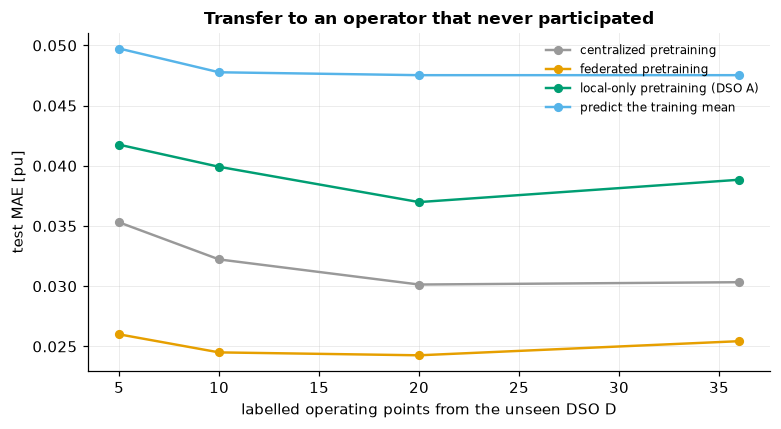

best encoder at 5 labels  : federated pretraining
best encoder at 36 labels : federated pretraining

Read this table as the experiment it is, and do not round it up into a
headline. The model is tiny, DSO D is deliberately the most distributionally
distant operator, and a single seed decides a lot at five labels.

If federated pretraining wins only in the low-label regime, that IS the
finding: the value of a shared representation is label efficiency on a
new operator, not a better ceiling. If centralized wins outright, that
is the measurable price of the privacy constraint. Either way the number
goes in the report unchanged.


In [24]:
@torch.no_grad()
def embed(model, graphs) -> torch.Tensor:
    """Mean-pooled encoder output per graph: the transferable artefact."""
    model.eval()
    out = []
    for graph in graphs:
        batch = collate_graphs([graph])
        hidden = model.encoder(batch)
        out.append(hidden.mean(dim=0))
    model.train()
    return torch.stack(out)


target_graphs = graph_data["DSO_D"]
target_y = torch.tensor(
    [[float(g["node_features"][:, 2].min())] for g in target_graphs],
    dtype=torch.float32,
)
split = int(0.6 * len(target_graphs))
train_graphs, test_graphs = target_graphs[:split], target_graphs[split:]
y_train_t, y_test_t = target_y[:split], target_y[split:]

encoders = {
    "local-only pretraining (DSO A)": local_gridfm,
    "centralized pretraining": central_gridfm,
    "federated pretraining": fed_gridfm,
}
BUDGETS = [5, 10, 20, split]

transfer_rows = []
for label, encoder in encoders.items():
    z_train = embed(encoder, train_graphs)
    z_test = embed(encoder, test_graphs)
    for budget in BUDGETS:
        if budget > len(z_train):
            continue
        set_seed()
        head = nn.Linear(z_train.shape[1], 1)
        optimiser = torch.optim.Adam(head.parameters(), lr=0.05)
        for _ in range(200):
            optimiser.zero_grad()
            loss = nn.functional.mse_loss(head(z_train[:budget]), y_train_t[:budget])
            loss.backward()
            optimiser.step()
        with torch.no_grad():
            mae = float((head(z_test) - y_test_t).abs().mean())
        transfer_rows.append({"encoder": label, "labels": budget, "MAE": mae})

# A no-pretraining control: predict the training mean.
for budget in BUDGETS:
    if budget > len(y_train_t):
        continue
    baseline = float((y_test_t - y_train_t[:budget].mean()).abs().mean())
    transfer_rows.append(
        {"encoder": "predict the training mean", "labels": budget, "MAE": baseline}
    )

transfer = (
    pd.DataFrame(transfer_rows)
    .pivot(index="labels", columns="encoder", values="MAE")
)
display(transfer.round(5))

fig, ax = plt.subplots(figsize=(7.2, 4.0))
for column in transfer.columns:
    ax.plot(transfer.index, transfer[column], "o-", ms=5, label=column)
ax.set_xlabel("labelled operating points from the unseen DSO D")
ax.set_ylabel("test MAE [pu]")
ax.set_title("Transfer to an operator that never participated")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

_low = transfer.loc[BUDGETS[0]].idxmin()
_high = transfer.loc[BUDGETS[-1]].idxmin()
print(f"best encoder at {BUDGETS[0]} labels  : {_low}")
print(f"best encoder at {BUDGETS[-1]} labels : {_high}")
print()
print("Read this table as the experiment it is, and do not round it up into a")
print("headline. The model is tiny, DSO D is deliberately the most distributionally")
print("distant operator, and a single seed decides a lot at five labels.")
print()
print("If federated pretraining wins only in the low-label regime, that IS the")
print("finding: the value of a shared representation is label efficiency on a")
print("new operator, not a better ceiling. If centralized wins outright, that")
print("is the measurable price of the privacy constraint. Either way the number")
print("goes in the report unchanged.")

## 21. Personalization

One global model for structurally different grids is a strong assumption. The
alternative is to split the model: share what generalises, keep what does not.

```text
shared encoder (federated)  +  local head (never leaves the DSO)
```

This is also the cleanest privacy story in the notebook — the personal
component is never transmitted at all, so it cannot be inverted from an
update.

In [25]:
set_seed()
shared_model, _ = run_federation(
    make_model, participants, n_rounds=N_ROUNDS, local_epochs=3, lr=0.02, seed=0
)

personalized = {}
for client in participants:
    model = copy.deepcopy(shared_model)
    # Freeze everything but the final layer: the shared body stays global.
    for param in model.parameters():
        param.requires_grad = False
    final = model[-1]
    for param in final.parameters():
        param.requires_grad = True
    optimiser = torch.optim.Adam(final.parameters(), lr=0.02)
    for _ in range(100):
        optimiser.zero_grad()
        loss = nn.functional.mse_loss(model(client.x_train), client.y_train)
        loss.backward()
        optimiser.step()
    personalized[client.name] = evaluate(model, client.x_valid, client.y_valid)

final_comparison = pd.DataFrame(
    {
        "local only": local_only,
        "centralized": centralized,
        "FedAvg": {n: fedavg[n] for n in local_only},
        "FedAvg + local head": personalized,
    }
)
final_comparison.loc["mean"] = final_comparison.mean()
final_comparison.loc["worst client"] = final_comparison.iloc[:-1].max()
final_comparison.loc["spread"] = final_comparison.iloc[:-2].std()
display(final_comparison.round(5))

print("Fairness across participants, not just the mean:")
for method in final_comparison.columns:
    print(f"  {method:22s} mean {final_comparison.loc['mean', method]:.5f}   "
          f"worst {final_comparison.loc['worst client', method]:.5f}   "
          f"spread {final_comparison.loc['spread', method]:.5f}")
print()
print("The question a federation has to answer is not 'is the average good'")
print("but 'does every participant benefit'. A DSO whose error is worse under")
print("FedAvg than alone is subsidising the others, and dataset-size weighting")
print("means the largest participant shapes the global model most. That is a")
print("governance problem as much as a statistical one.")

,local only,centralized,FedAvg,FedAvg + local head
DSO_A,0.03555,0.03422,0.02948,0.01079
DSO_B,0.03183,0.05728,0.06363,0.01413
DSO_C,0.04224,0.02908,0.03096,0.01102
mean,0.03654,0.04019,0.04136,0.01198
worst client,0.04224,0.05728,0.06363,0.01413
spread,0.00528,0.01502,0.01930,0.00187


Fairness across participants, not just the mean:
  local only             mean 0.03654   worst 0.04224   spread 0.00528
  centralized            mean 0.04019   worst 0.05728   spread 0.01502
  FedAvg                 mean 0.04136   worst 0.06363   spread 0.01930
  FedAvg + local head    mean 0.01198   worst 0.01413   spread 0.00187

The question a federation has to answer is not 'is the average good'
but 'does every participant benefit'. A DSO whose error is worse under
FedAvg than alone is subsidising the others, and dataset-size weighting
means the largest participant shapes the global model most. That is a
governance problem as much as a statistical one.


## 22. Client participation and dropout

Cross-device federations assume most clients are missing most of the time.
Cross-silo federations are contractual and far more stable — but a partner can
still be down for maintenance, and a four-party federation losing one party
has lost a quarter of its data.

In [26]:
participation_rows = []
for rate in (1.0, 0.67, 0.34):
    set_seed()
    _, history = run_federation(
        make_model, participants, n_rounds=N_ROUNDS, local_epochs=3, lr=0.02,
        participation=rate, seed=0,
    )
    participation_rows.append(
        {
            "participation": rate,
            "clients per round": max(1, int(round(rate * len(participants)))),
            "final mean MAE": history.global_mae[-1],
            "worst client": history.worst_client(),
            "communication per round [KiB]": (
                2 * max(1, int(round(rate * len(participants))))
                * state_dict_bytes(make_model().state_dict()) / 1024
            ),
        }
    )
display(pd.DataFrame(participation_rows).set_index("participation").round(5))

print("Lower participation means less communication and less data per round.")
print("With only three participants the effect is coarse -- dropping one is a")
print("33% loss -- which is itself the lesson about small cross-silo")
print("federations: there is no law of large numbers to hide behind.")

,clients per round,final mean MAE,worst client,communication per round [KiB]
participation,,,,
1.00,3,0.08865,0.10715,19.52344
0.67,2,0.08658,0.10851,13.01562
0.34,1,0.08985,0.10222,6.50781


Lower participation means less communication and less data per round.
With only three participants the effect is coarse -- dropping one is a
33% loss -- which is itself the lesson about small cross-silo
federations: there is no law of large numbers to hide behind.


## 23. What we have not solved

### Model heterogeneity

FedAvg requires every client to hold the *same architecture*, because it
averages tensors position by position. Real operators have different compute
budgets and different legacy stacks. Approaches that relax this — knowledge
distillation through a public proxy dataset, exchanging embeddings rather than
weights, heterogeneous adapter ranks (FlexLoRA, HeLoRA) — are active research,
and none is a drop-in replacement.

### Modality heterogeneity

Worse, and specific to this domain. Operators do not observe the same things:

```text
DSO A   SCADA + topology + weather
DSO B   smart meters + topology
DSO C   PMU + SCADA
DSO D   topology + smart meters + market data
```

What should be federated when participants do not share an input space? The
candidates are modality-specific encoders feeding a shared latent space, or
training with missing modalities by construction. FediLoRA (2025) is one recent
attempt in the multimodal federated setting. This is unsolved.

### Federated analytics

Not every collaborative computation needs training. Aggregate load statistics,
the prevalence of voltage violations, or **normalisation constants** can be
computed federatedly. The last one matters here: §4 standardised each client
with its *own* statistics precisely to avoid a hidden centralization step.
Computing one global mean and variance would have been a federated analytics
problem in its own right — small, but not free.

### What is actually sensitive?

Not every column deserves the same protection, and treating them uniformly is
both expensive and imprecise. As a discussion exercise, classify:

| Information | Personal? | Commercially sensitive? | Infrastructure-sensitive? |
|---|---|---|---|
| network topology | no | often | **yes** |
| line and transformer parameters | no | sometimes | yes |
| 15-minute transformer loading | no | yes | yes |
| individual smart-meter readings | **yes** | yes | no |
| aggregated feeder load | no | sometimes | maybe |
| weather | no | no | no |
| market prices | no | varies | no |
| outage logs | sometimes | yes | **yes** |

The right *privacy unit* follows from this and is not obvious: one
measurement, one household, one feeder, or one DSO? Differential privacy
guarantees are stated per unit, so the choice determines what the epsilon
means. Legal classification depends on jurisdiction and context, and nothing
here is legal advice.

## 24. Limitations of this notebook

Stated plainly, because a small federated experiment invites over-reading.

- **Four clients, and simulated.** Virtual clients in one process reproduce
  the *algorithm*, not the systems reality: no network latency, no
  stragglers, no partial failure, no transport security, no attestation.
- **Small models and few rounds.** Classroom mode runs on a laptop CPU. Any
  ranking between methods here is one seed on one small problem.
- **No formal privacy guarantee anywhere.** §13 adds noise and measures the
  utility cost. It does not implement a mechanism or an accountant, and no
  epsilon is quoted because none was computed.
- **Secure aggregation is described, not implemented.** The sum is computed in
  plaintext.
- **The synthetic DSOs are pandapower networks with perturbed injections.**
  The heterogeneity is real and measured, but it is not the heterogeneity of
  four actual European operators.
- **The transfer result is one target grid and one seed.** It shows a
  methodology working, not a benchmark.

## 25. Exercises

See `tutorials/exercise.ipynb`, chapter 11 — seven tasks covering FedAvg by
hand, building a federation round, analysing non-IID clients, communication
accounting, federated LoRA, a written critique of a privacy claim, and a
design exercise for a Federated GridFM.

## 26. Key takeaways

1. **Federated learning is an architecture, not a privacy guarantee.** Raw
   training samples stay local. Updates leave, and updates are a function of
   the data — §12 measured how reliably.
2. **Heterogeneity is the central difficulty**, and in power systems it
   includes concept shift: the same injections produce different voltages on
   different topologies, so clients genuinely disagree about the function
   being learned.
3. **A mean over clients hides the client the federation is failing.** Report
   per-client metrics, the worst case and the spread. Always.
4. **More local computation trades communication for drift.** Both directions
   are real; which wins is an empirical question about your federation.
5. **FedProx costs one term and buys drift control** — measurably, and not
   always accuracy.
6. **Privacy mechanisms solve different problems.** Data locality, secure
   aggregation and differential privacy are three things, and naming a threat
   model comes before choosing between them.
7. **Foundation models break naive federation by arithmetic** — a billion
   parameters over a hundred clients and a hundred rounds is petabytes. This
   is what makes federated PEFT a precondition rather than an optimisation.
8. **Federated LoRA moves adapters, not backbones**, and the saving is large
   but should be quoted against both directions and against the one-time cost
   of distributing the frozen model.
9. **Self-supervised objectives are what make pretraining federatable** — no
   labels means no need for participants to agree on a label schema.
10. **The two paradigm shifts are independent.** Task-specific → foundation
    model is about generality; centralized → federated is about where data
    lives. Federated foundation models are the corner where both apply.

## 27. Open research questions

The tutorial ends here; the field does not.

- What should be shared between operators — parameters, gradients, adapters,
  embeddings, or prototypes?
- Is it a *foundation* model if every DSO needs extensive local retraining?
- How structurally different can topologies become before weight averaging
  stops meaning anything?
- Should a grid foundation model have one global encoder and operator-specific
  decoders?
- How should a federation span operators at different voltage levels?
- How do you validate that a learned representation has *not* encoded
  something sensitive?
- What is the right privacy unit: a measurement, a household, a feeder, or an
  operator?
- Can differential privacy preserve the rare events — the unusual outage, the
  near-violation — that are the most valuable to learn from and the most
  identifying?
- How do you measure whether each participant benefits fairly, and how should
  contributions be rewarded when they differ by orders of magnitude?
- Could one participant poison a model that every other operator then relies
  on?
- How is a federated grid model maintained as networks evolve over a decade?

## 28. Further reading

**Federated learning**

- McMahan et al., "Communication-Efficient Learning of Deep Networks from
  Decentralized Data", AISTATS 2017 —
  [arXiv:1602.05629](https://arxiv.org/abs/1602.05629). FedAvg.
- Li et al., "Federated Optimization in Heterogeneous Networks", MLSys 2020 —
  [arXiv:1812.06127](https://arxiv.org/abs/1812.06127). FedProx.
- Karimireddy et al., "SCAFFOLD: Stochastic Controlled Averaging for Federated
  Learning", ICML 2020 — [arXiv:1910.06378](https://arxiv.org/abs/1910.06378).
- Kairouz et al., "Advances and Open Problems in Federated Learning",
  *Foundations and Trends in ML* 14(1–2), 2021 —
  [arXiv:1912.04977](https://arxiv.org/abs/1912.04977). The reference survey.

**Privacy and security**

- Zhu, Liu & Han, "Deep Leakage from Gradients", NeurIPS 2019 —
  [arXiv:1906.08935](https://arxiv.org/abs/1906.08935).
- Geiping et al., "Inverting Gradients — How easy is it to break privacy in
  federated learning?", NeurIPS 2020 —
  [arXiv:2003.14053](https://arxiv.org/abs/2003.14053).
- Bonawitz et al., "Practical Secure Aggregation for Privacy-Preserving
  Machine Learning", CCS 2017.
- Abadi et al., "Deep Learning with Differential Privacy", CCS 2016 —
  [arXiv:1607.00133](https://arxiv.org/abs/1607.00133). DP-SGD and the moments
  accountant.

**Federated foundation models**

- Ren et al., "Advances and Open Challenges in Federated Foundation Models",
  2024 — [arXiv:2404.15381](https://arxiv.org/abs/2404.15381).
- Woisetschläger et al., "A Survey on Efficient Federated Learning Methods for
  Foundation Model Training", IJCAI 2024 —
  [arXiv:2401.04472](https://arxiv.org/abs/2401.04472).
- Hatfaludi & Serban, "Foundational models and federated learning: survey,
  taxonomy, challenges and practical insights", 2025 —
  [arXiv:2509.05142](https://arxiv.org/abs/2509.05142).
- Zhuang, Chen & Lyu, "When Foundation Model Meets Federated Learning", 2023 —
  [arXiv:2306.15546](https://arxiv.org/abs/2306.15546).

**Federated PEFT**

- Hu et al., "LoRA: Low-Rank Adaptation of Large Language Models", ICLR 2022 —
  [arXiv:2106.09685](https://arxiv.org/abs/2106.09685).
- Sun et al., "Improving LoRA in Privacy-Preserving Federated Learning", ICLR
  2024 — [arXiv:2403.12313](https://arxiv.org/abs/2403.12313). FFA-LoRA.
- Bai et al., "Federated Fine-tuning of Large Language Models under
  Heterogeneous Tasks and Client Resources", NeurIPS 2024 —
  [arXiv:2402.11505](https://arxiv.org/abs/2402.11505). FlexLoRA.

**Power systems**

- Wen et al., "Federated Learning for Smart Grid: A Survey on Applications and
  Potential Vulnerabilities", 2024 —
  [arXiv:2409.10764](https://arxiv.org/abs/2409.10764).
- Hamann et al., "Foundation Models for the Electric Power Grid", *Joule*,
  2024 — [arXiv:2407.09434](https://arxiv.org/abs/2407.09434).

**Software**

- Beutel et al., "Flower: A Friendly Federated Learning Research Framework",
  2020 — [arXiv:2007.14390](https://arxiv.org/abs/2007.14390) ·
  [flower.ai](https://flower.ai)
- Opacus — DP-SGD for PyTorch, with a working accountant.